In [1]:
import pandas as pd

train_data = pd.read_csv("../datasets/churn_training_dataset.csv")
train_data.head()
print(train_data.info())

test_data = pd.read_csv("../datasets/telco_testing_dataset.csv")
test_data.head()
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     

In [2]:
import mysql.connector

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="churn_prediction"
)
cursor = conn.cursor()

In [3]:
# Standardize column names
test_data.rename(columns={"customerID": "CustomerID","gender":"Gender", "tenure": "Tenure"}, inplace=True)


# Select COMMON columns only
common_cols = ["CustomerID", "Gender", "Tenure", "MonthlyCharges",
               "Contract", "PaymentMethod", "TotalCharges", "Churn"]

train_data = train_data[common_cols]
test_data = test_data[common_cols]


# Data Cleaning
for df in [train_data, test_data]:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Insert TRAIN data
sql_train = """
INSERT INTO customers_train
(CustomerID, Gender, Tenure, MonthlyCharges, Contract, PaymentMethod, TotalCharges, Churn)
VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
"""

train_values = [tuple(row) for row in train_data.to_numpy()]
cursor.executemany(sql_train, train_values)
conn.commit()

print("Train data inserted")


# Insert TEST data
sql_test = """
INSERT INTO customers_test
(CustomerID, Gender, Tenure, MonthlyCharges, Contract, PaymentMethod, TotalCharges, Churn)
VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
"""

test_values = [tuple(row) for row in test_data.to_numpy()]
cursor.executemany(sql_test, test_values)
conn.commit()

print("Test data inserted")

# Close connection
cursor.close()
conn.close()

Train data inserted
Test data inserted


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

# Encode categorical variables
# For simplicity, we use pd.get_dummies 
categorical_cols = ['Gender', 'Contract', 'PaymentMethod']
train_data_encoded = pd.get_dummies(train_data, columns=categorical_cols, drop_first=True)
test_data_encoded = pd.get_dummies(test_data, columns=categorical_cols, drop_first=True)

# Ensuring both train and test have same columns after encoding
train_cols = train_data_encoded.columns
test_data_encoded = test_data_encoded.reindex(columns=train_cols, fill_value=0)

# Split features and target
X_train = train_data_encoded.drop(['CustomerID', 'Churn'], axis=1)
y_train = train_data_encoded['Churn'].apply(lambda x: 1 if x=='Yes' else 0)

X_test = test_data_encoded.drop(['CustomerID', 'Churn'], axis=1)
y_test = test_data_encoded['Churn'].apply(lambda x: 1 if x=='Yes' else 0)

# Feature Scaling (Normalize numerical features) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# Train and Evaluate
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Print detailed report
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, y_pred))
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1
    })

# Compare Results
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n Model Comparison:\n")
print(results_df)


Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      5174
           1       0.54      0.71      0.61      1869

    accuracy                           0.76      7043
   macro avg       0.71      0.74      0.72      7043
weighted avg       0.79      0.76      0.77      7043


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      5174
           1       0.51      0.60      0.55      1869

    accuracy                           0.74      7043
   macro avg       0.68      0.70      0.69      7043
weighted avg       0.76      0.74      0.75      7043


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      5174
           1       0.48      0.54      0.50      1869

    accuracy                           0.72      7043
   ma

In [6]:
import joblib

# Use the exact key: "Logistic Regression"
best_model = models["Logistic Regression"]

# Save the final model and the scaler used
joblib.dump(best_model, 'best_churn_model.pkl') 
joblib.dump(scaler, 'scaler.pkl')

joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

print("All files saved successfully for the UI!") 

All files saved successfully for the UI!


/Users/siddhi/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


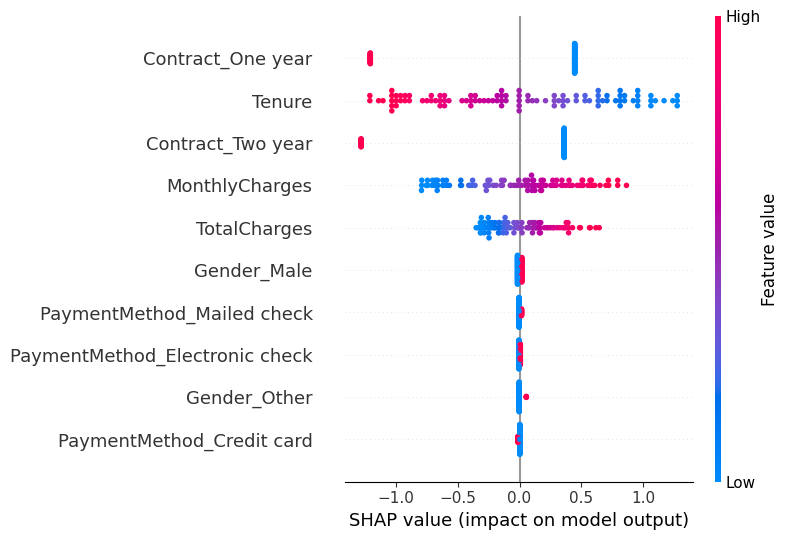

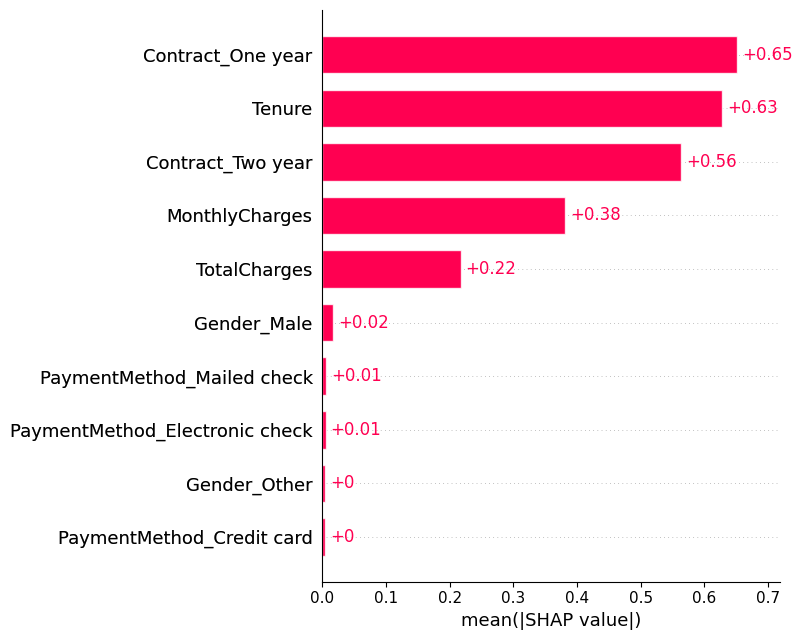

In [7]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data
X_sample = pd.DataFrame(X_train_scaled, columns=X_train.columns).sample(100, random_state=42)

# 2. Create Explainer
explainer = shap.Explainer(best_model, X_sample) #background data ("reference" version of your model)
shap_values = explainer(X_sample) #data to explain 

# 3. Summary Plot 
# We use plt.subplots to control the layout
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False) # show=False lets us tweak it
plt.tight_layout() 
plt.show() 

# 4. Bar Plot
fig, ax = plt.subplots(figsize=(10, 6))
# Using the modern bar plot method for cleaner results
shap.plots.bar(shap_values, show=False) 
plt.tight_layout()
plt.show()


 ANALYZING RANDOM CUSTOMER: Index 2463
Model Prediction: CHURN (Confidence: 65.30%)


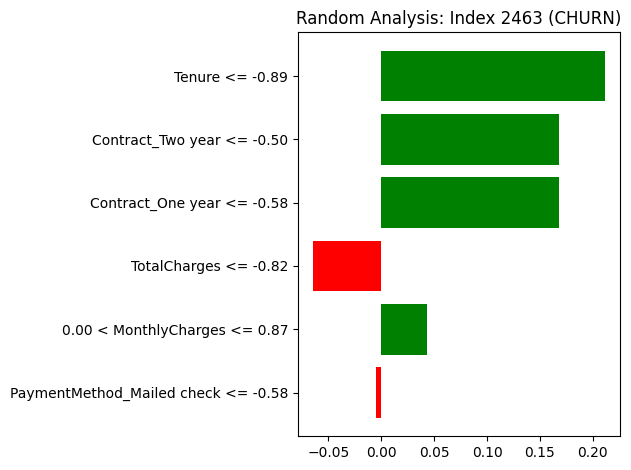


 ANALYZING RANDOM CUSTOMER: Index 3377
Model Prediction: STAY (Confidence: 97.73%)


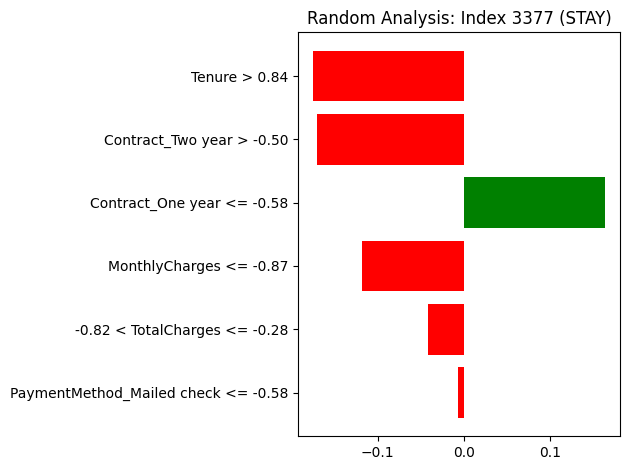

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_tabular

# 1. SETUP THE EXPLAINER
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=list(X_train.columns),
    class_names=['No Churn', 'Churn'],
    mode='classification'
)

# 2. RANDOM SELECTION of customer from the dataset
random_stay_idx = np.random.randint(0, len(X_test_scaled))
random_churn_idx = np.random.randint(0, len(X_test_scaled))

# 3. 2 random customers selected 
for name, idx in [("RANDOM_A", random_stay_idx), ("RANDOM_B", random_churn_idx)]:
    print(f"\n ANALYZING RANDOM CUSTOMER: Index {idx}")
    
    # Get the prediction for this specific random person
    prob = best_model.predict_proba(X_test_scaled[idx].reshape(1, -1))[0]
    prediction = "CHURN" if prob[1] > 0.5 else "STAY"
    
    print(f"Model Prediction: {prediction} (Confidence: {max(prob)*100:.2f}%)")

    exp = explainer.explain_instance(
        X_test_scaled[idx], 
        best_model.predict_proba, 
        num_features=6
    )
    
    # Display the bars
    exp.show_in_notebook(show_table=True)
    
    # Save the file (it will overwrite the old one each time)
    fig = exp.as_pyplot_figure()
    plt.title(f"Random Analysis: Index {idx} ({prediction})")
    plt.tight_layout()
    plt.savefig(f'random_case_{name}.png')
    plt.show()

FINAL TEST ACCURACY: 75.99%

 DETAILED CLASSIFICATION REPORT 
              precision    recall  f1-score   support

        Stay       0.88      0.78      0.83      5174
       Churn       0.54      0.71      0.61      1869

    accuracy                           0.76      7043
   macro avg       0.71      0.74      0.72      7043
weighted avg       0.79      0.76      0.77      7043



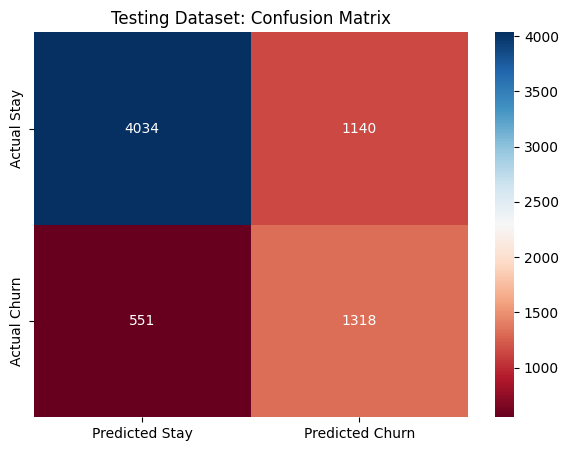


 PREDICTION CHECK (FIRST 10 TEST SAMPLES)
   Actual_Value  Predicted_Value  Churn_Probability
0             0                1           0.524652
1             0                0           0.106928
2             1                1           0.600785
3             0                0           0.061935
4             1                1           0.640122
5             1                1           0.689745
6             0                1           0.583687
7             0                0           0.455225
8             1                1           0.605721
9             0                0           0.049873


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. MAKE PREDICTIONS ON THE TEST DATASET
# X_test_scaled is 'unseen' data from telco_testing_dataset.csv
y_pred = best_model.predict(X_test_scaled)
y_probs = best_model.predict_proba(X_test_scaled)[:, 1] # Probability of Churn

# 2. OVERALL ACCURACY
accuracy = accuracy_score(y_test, y_pred)
print(f"FINAL TEST ACCURACY: {accuracy*100:.2f}%")

# 3. CLASSIFICATION REPORT
# This shows Precision (exactness) and Recall (completeness)
print("\n DETAILED CLASSIFICATION REPORT ")
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

# 4. CONFUSION MATRIX
# This shows exactly where the model got 'confused'
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu', 
            xticklabels=['Predicted Stay', 'Predicted Churn'], 
            yticklabels=['Actual Stay', 'Actual Churn'])
plt.title("Testing Dataset: Confusion Matrix")
plt.show()

# 5. TEST SAMPLE CHECK
# Let's look at the first 10 rows of the test set to see if the model was right
results_check = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred,
    'Churn_Probability': y_probs
}).head(10)

print("\n PREDICTION CHECK (FIRST 10 TEST SAMPLES)")
print(results_check)